In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, SubsetRandomSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# PyTorch Dataset
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
# Load data
current_dir = os.getcwd()
path_train = current_dir + "/../dataset/mitbih/" + "mitbih_train.csv"
path_test = current_dir + "/../dataset/mitbih/" + "mitbih_test.csv"

df_train = pd.read_csv(path_train, header=None)
df_test = pd.read_csv(path_test, header=None)

# Drop any non-numeric column (like 'Class' from the header row)
df_train = df_train.apply(pd.to_numeric, errors='coerce')
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Remove any NaN values (in case 'Class' was still causing issues)
#df_train = df_train.dropna()
#df_test = df_test.dropna()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Split features and labels
X_train, y_train = df_train.iloc[:, :-1].values, df_train.iloc[:, -1].values
X_test, y_test = df_test.iloc[:, :-1].values, df_test.iloc[:, -1].values

reduction_factor = 0.25  # Keep 25% of the dataset

# Dataloaders
train_valid_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

batch_size = 32
train_size = int(0.8 * len(train_valid_dataset))
val_size = len(train_valid_dataset) - train_size
train_dataset, val_dataset = random_split(train_valid_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Squeeze: Global average pooling
        b, c, _ = x.size()
        squeeze = F.adaptive_avg_pool1d(x, 1).view(b, c)
        excite = self.fc1(squeeze)
        excite = F.relu(excite)
        excite = self.fc2(excite)
        excite = self.sigmoid(excite).view(b, c, 1)
        return x * excite.expand_as(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, in_channels, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.in_channels = in_channels
        self.head_dim = in_channels // num_heads
        
        # Ensure the in_channels is divisible by num_heads
        assert in_channels % num_heads == 0, "in_channels must be divisible by num_heads"
        
        self.query = nn.Linear(in_channels, in_channels)
        self.key = nn.Linear(in_channels, in_channels)
        self.value = nn.Linear(in_channels, in_channels)
        self.out = nn.Linear(in_channels, in_channels)
        
    def forward(self, x):
        batch_size, seq_length, _ = x.size()
        
        # Linear projections
        query = self.query(x).view(batch_size, seq_length, self.num_heads, self.head_dim)
        key = self.key(x).view(batch_size, seq_length, self.num_heads, self.head_dim)
        value = self.value(x).view(batch_size, seq_length, self.num_heads, self.head_dim)
        
        # Permute for multi-head attention
        query = query.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_length, head_dim)
        key = key.permute(0, 2, 1, 3)      # (batch_size, num_heads, seq_length, head_dim)
        value = value.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_length, head_dim)
        
        # Scaled dot-product attention
        scores = torch.matmul(query, key.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attention = torch.softmax(scores, dim=-1)
        
        # Attention output
        out = torch.matmul(attention, value)  # (batch_size, num_heads, seq_length, head_dim)
        
        # Concatenate the heads and apply the output linear transformation
        out = out.permute(0, 2, 1, 3).contiguous().view(batch_size, seq_length, self.in_channels)
        out = self.out(out)
        
        return out

class CNN_GRU_SE_ResNet_Attention(nn.Module):
    def __init__(self, input_size=187, num_classes=5, num_heads=8):
        super(CNN_GRU_SE_ResNet_Attention, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=1, stride=2)
        
        # Additional non-linear convolution (with different kernel sizes)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        
        # Temporal convolution for long-term dependencies
        self.temp_conv = nn.Conv1d(in_channels=128, out_channels=128, kernel_size=9, stride=1, padding=4)
        self.bn_temp = nn.BatchNorm1d(128)
        self.relu_temp = nn.ReLU()
        
        # GRU Layer
        self.gru = nn.GRU(input_size=128, hidden_size=128, num_layers=4, batch_first=True)
        
        # SEBlock
        self.se_block = SEBlock(channels=128)
        
        # Multi-Head Attention
        self.multi_head_attention = MultiHeadAttention(in_channels=128, num_heads=num_heads)

        # Linear layer to project GRU output to the required size (128)
        self.project_gru = nn.Linear(128, 128)

        # Calculate the output size after convolutions and GRU
        dummy_input = torch.zeros(1, 1, input_size)  # Batch size = 1, channels = 1, input_size = input_size
        dummy_output = self._forward_convs(dummy_input)
        dummy_output = dummy_output.transpose(1, 2)  # To match GRU input shape
        gru_output, _ = self.gru(dummy_output)  # Pass through GRU
        gru_output = self.project_gru(gru_output)  # Project GRU output to 128
        flattened_size = gru_output.size(1) * gru_output.size(2)  # Flattened size after GRU
        
        # Fully Connected Layer
        self.fc = nn.Linear(flattened_size, num_classes)  # Adjusted size based on GRU output

    def _forward_convs(self, x):
        # Convolution + Batch Norm + ReLU + Pooling
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool(x)

        x = self.temp_conv(x)
        x = self.bn_temp(x)
        x = self.relu_temp(x)
        x = self.pool(x)
        
        return x

    def forward(self, x):
        # Pass through convolutions and get the output
        x = self._forward_convs(x)
        
        # Apply Squeeze-and-Excitation Block
        x = self.se_block(x)
        
        # Reshape for GRU
        x = x.transpose(1, 2)  # (batch_size, seq_length, channels)
        
        # GRU layer
        x, _ = self.gru(x)
        
        # Project GRU output to 128 (the size expected by attention)
        x = self.project_gru(x)
        
        # Apply Multi-Head Attention
        x = self.multi_head_attention(x)
        
        # Flatten the output for fully connected layer
        x = x.contiguous().view(x.size(0), -1)  # Flatten the output
        
        # Fully connected layer for final classification
        x = self.fc(x)
        return x


In [5]:
# Calculate class weights for y_train
class_weights = compute_class_weight(
    class_weight='balanced',  # 'balanced' will automatically compute the weights based on the frequency of the classes
    classes=np.unique(y_train),  # List of unique classes in y_train
    y=y_train                   # The target labels
)

# Convert to tensor for PyTorch compatibility
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)


tensor([ 0.2416,  7.8771,  3.0254, 27.3179,  2.7229])


In [6]:
model = CNN_GRU_SE_ResNet_Attention().to(device)
criterion = nn.CrossEntropyLoss()
loss_fn = criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)
print(device)

CNN_GRU_SE_ResNet_Attention(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=1, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (temp_conv): Conv1d(128, 128, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn_temp): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu_temp): ReLU()
  (gru): GRU(128, 128, num_layers=4, batch_first=True)
  (se_block): SEBlock(
    (fc1): Linear(in_features=128, out_features=8, bias=True)
    (fc2): Linear(i

In [7]:
# Training Loop
epochs = 40
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    # Compute average training loss
    train_loss = running_loss / len(train_loader)
    # Validation Phase
    model.eval()
    val_loss = 0.0
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Compute average validation loss
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    


Epoch 1, Loss: 0.2007
Epoch 1: Train Loss: 0.2007, Val Loss: 0.1304
Epoch 2, Loss: 0.1092
Epoch 2: Train Loss: 0.1092, Val Loss: 0.0806
Epoch 3, Loss: 0.0839
Epoch 3: Train Loss: 0.0839, Val Loss: 0.1274
Epoch 4, Loss: 0.0706
Epoch 4: Train Loss: 0.0706, Val Loss: 0.0637
Epoch 5, Loss: 0.0587
Epoch 5: Train Loss: 0.0587, Val Loss: 0.0546
Epoch 6, Loss: 0.0508
Epoch 6: Train Loss: 0.0508, Val Loss: 0.0556
Epoch 7, Loss: 0.0455
Epoch 7: Train Loss: 0.0455, Val Loss: 0.0572
Epoch 8, Loss: 0.0401
Epoch 8: Train Loss: 0.0401, Val Loss: 0.0594
Epoch 9, Loss: 0.0364
Epoch 9: Train Loss: 0.0364, Val Loss: 0.0564
Epoch 10, Loss: 0.0326
Epoch 10: Train Loss: 0.0326, Val Loss: 0.0611
Epoch 11, Loss: 0.0302
Epoch 11: Train Loss: 0.0302, Val Loss: 0.0618
Epoch 12, Loss: 0.0271
Epoch 12: Train Loss: 0.0271, Val Loss: 0.0576
Epoch 13, Loss: 0.0254
Epoch 13: Train Loss: 0.0254, Val Loss: 0.0627
Epoch 14, Loss: 0.0235
Epoch 14: Train Loss: 0.0235, Val Loss: 0.0597
Epoch 15, Loss: 0.0213
Epoch 15: Train

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18118
           1       0.89      0.79      0.84       556
           2       0.97      0.95      0.96      1448
           3       0.88      0.74      0.80       162
           4       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.89      0.92     21892
weighted avg       0.98      0.98      0.98     21892


Performance Metrics:
              precision    recall  f1-score
0              0.988871  0.995529  0.992189
1              0.891837  0.785971  0.835564
2              0.969144  0.954420  0.961726
3              0.875912  0.740741  0.802676
4              0.988118  0.982587  0.985345
accuracy       0.984652  0.984652  0.984652
macro avg      0.942776  0.891850  0.915500
weighted avg   0.984210  0.984652  0.984291


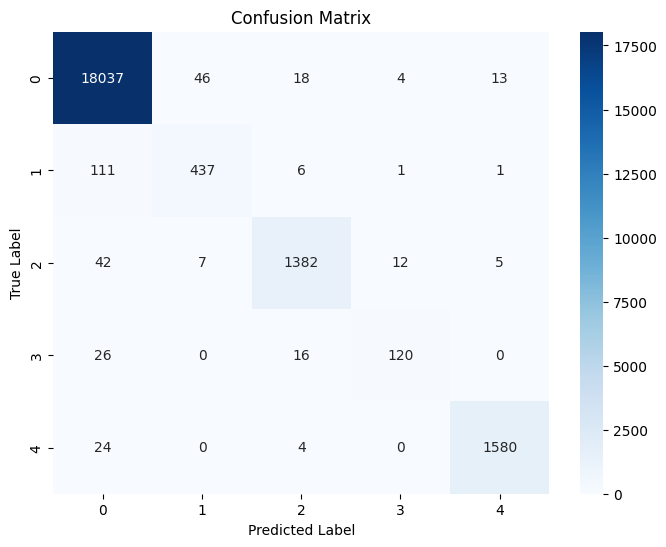

In [8]:
# Evaluate the model
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# Print classification report
print(classification_report(y_true, y_pred))

# Generate classification report
report = classification_report(y_true, y_pred, output_dict=True)

# Performance metrics table
metrics_table = pd.DataFrame(report).transpose()

# Display the table
print("\nPerformance Metrics:")
print(metrics_table[['precision', 'recall', 'f1-score']])

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# path = "models_save/"
# model_save = path + "CNN_model.pth"
# #Save Trained Model:
# torch.save(model.state_dict(), model_save)
# print("Model saved successfully.")